# N1 · masked diffusion 语言模型: 并行迭代解码

> 配套 13.6-L1 · 文本也能扩散。玩具「语言」= 回文序列 [a,b,c,c,b,a]。
> 手搭一个 masked diffusion LM (dLLM): 从全 [MASK] 出发, **按置信度并行迭代解码**生成文本。
> 看非自回归生成长什么样, 以及「并行度 vs 质量」的权衡 (呼应 M13.2 采样步数)。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np, torch
import diffusion_lm as dl
print('diffusion_lm 就绪; 词表', dl.V, '长度', dl.L, '[MASK]id', dl.MASK)

diffusion_lm 就绪; 词表 6 长度 6 [MASK]id 6


## 1. 玩具语言: 回文 (位置 i 必须等于位置 L-1-i)

In [2]:
data = dl.make_sequences(2000, seed=0)
print('回文数据', data.shape, '合法率', dl.is_palindrome(data))
for s in data[:5]: print('  ', s)

回文数据 (2000, 6) 合法率 1.0
   [5 3 3 3 3 5]
   [1 1 0 0 1 1]
   [0 0 1 1 0 0]
   [4 3 5 5 3 4]
   [3 3 5 5 3 3]


## 2. 训练 dLLM (随机比例遮盖, 只在被遮位预测原 token = masked diffusion)

In [3]:
torch.manual_seed(0)
dlm = dl.build_dlm(d_model=80)
losses = dl.train_dlm(dlm, data, epochs=800)
print(f'dLLM 训练: loss {losses[0]:.3f} → {losses[-1]:.3f}')

dLLM 训练: loss 2.163 → 0.738


## 3. 看一条序列的并行解码轨迹 (从全 [MASK] 逐轮填充)

解码轨迹 (6=[MASK]):
  轮0: [6 6 6 6 6 6]
  轮1: [6 5 6 6 6 4]
  轮2: [4 5 6 6 5 4]
  轮3: [4 5 4 4 5 4]


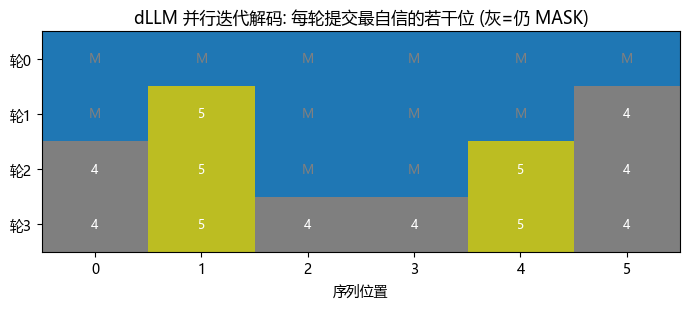

→ 不是左到右一个个生成, 而是"哪里有把握先填哪里", 多位并行 (非自回归)。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
gen, traj = dl.generate_dlm(dlm, n=200, rounds=3, seed=1, record=True)
print('解码轨迹 (6=[MASK]):')
for i, s in enumerate(traj):
    print(f'  轮{i}: {s}')
# 可视化: 每轮哪些位被填上
fig, ax = plt.subplots(figsize=(7,3.2))
arr = np.array(traj)
import numpy as np
show = np.where(arr==dl.MASK, -1, arr)
im = ax.imshow(show, cmap='tab10', vmin=-1, vmax=dl.V, aspect='auto')
ax.set_yticks(range(len(traj))); ax.set_yticklabels([f'轮{i}' for i in range(len(traj))])
ax.set_xlabel('序列位置'); ax.set_title('dLLM 并行迭代解码: 每轮提交最自信的若干位 (灰=仍 MASK)')
for i in range(len(traj)):
    for j in range(dl.L):
        v = arr[i,j]
        ax.text(j, i, 'M' if v==dl.MASK else str(v), ha='center', va='center', fontsize=9,
                color='gray' if v==dl.MASK else 'white')
plt.tight_layout(); plt.show()
print('→ 不是左到右一个个生成, 而是"哪里有把握先填哪里", 多位并行 (非自回归)。')

## 4. 并行度 vs 质量: 解码轮数的权衡 (呼应 M13.2 采样步数)

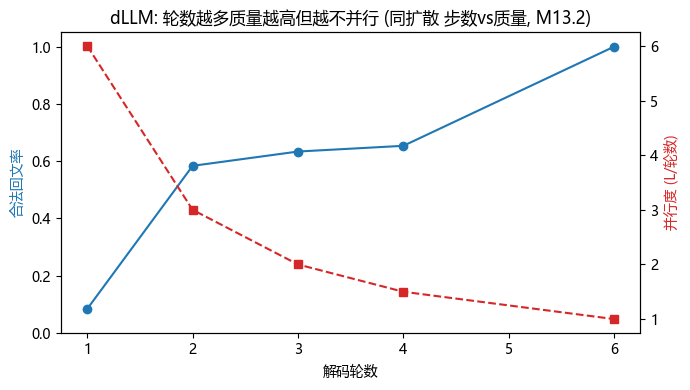

合法率: {1: 0.08, 2: 0.58, 3: 0.63, 4: 0.65, 6: 1.0}
→ 轮数=1 全并行但质量低; 轮数=L 退化为顺序解码但质量满分。这就是 dLLM 的核心旋钮。


In [5]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
rounds_list = [1,2,3,4,6]
valid = [dl.is_palindrome(dl.generate_dlm(dlm, n=300, rounds=r, seed=1)) for r in rounds_list]
parallel = [dl.L/r for r in rounds_list]
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(rounds_list, valid, 'o-', color='C0', label='合法率')
ax1.set_xlabel('解码轮数'); ax1.set_ylabel('合法回文率', color='C0'); ax1.set_ylim(0,1.05)
ax2 = ax1.twinx(); ax2.plot(rounds_list, parallel, 's--', color='C3', label='并行度')
ax2.set_ylabel('并行度 (L/轮数)', color='C3')
plt.title('dLLM: 轮数越多质量越高但越不并行 (同扩散 步数vs质量, M13.2)')
fig.tight_layout(); plt.show()
print('合法率:', {r:round(v,2) for r,v in zip(rounds_list,valid)})
print('→ 轮数=1 全并行但质量低; 轮数=L 退化为顺序解码但质量满分。这就是 dLLM 的核心旋钮。')

## 5. 反思
你手搭了一个 dLLM 并看它**并行解码**生成文本。带走:
- **masked diffusion**: 前向逐步遮盖 token, 模型学「填被遮位」; 生成 = 从全 [MASK] 按置信度迭代填。
- **非自回归**: 不是左到右一个个吐, 而是「有把握先填」, 多位并行 (区别于 AR 的本质)。
- **并行度 vs 质量旋钮**: 轮数少更并行但质量低, 轮数多更准但更慢 —— 和扩散的步数vs质量 (M13.2) 同构。
下一步 N2: dLLM 比 AR 强在哪? 看**双向 infilling** (dLLM 杀手锏)。